# Example: Building the Cobb-Douglas Allocator

In this example, we pick up the portfolio you built in Session 1 and show how to drive it adaptively. We load the user-selected universe and calibrated SIM parameters from the Session 1 min-var notebook, generate a single hybrid-SIM forward path via [`generate_hybrid_scenario(...)`](../../code/docs/build/session1.html), compute the EMA crossover sentiment signal, and solve the **Cobb-Douglas utility maximization** problem at each trading day. We then compare Cobb-Douglas against two alternatives: CES and log-linear utility.

> __Learning Objectives:__
>
> * __Generate synthetic prices and sentiment:__ Load the calibrated SIM parameters from Session 1 and generate a single forward path via the hybrid-SIM surrogate. Compute the EMA-crossover sentiment signal and feed it into the preference weight calculation.
> * __Solve the Cobb-Douglas allocation:__ Solve the budget-constrained Cobb-Douglas allocation problem analytically to obtain optimal share counts. The closed-form solution routes capital toward preferred assets while maintaining a minimum floor for non-preferred ones.
> * __Compare utility function behavior:__ Compare allocation behavior across Cobb-Douglas, CES, and log-linear utility functions under the same preference weights. The choice of utility function controls portfolio concentration even when preferences are held fixed.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

### Constants


In [2]:
# Allocator configuration
B₀ = 10_000.0               # starting budget (USD)
Δt = 1.0 / 252.0            # trading-day step (years)
L_short = 21                # short EMA window (days)
L_long = 63                 # long EMA window (days)
L_growth = 10               # EMA window for smoothed market growth rate (days)
GAIN = 10.0                 # gain constant G for λ signal (dimensionless)
offset = L_short + L_long   # warmup offset before trading begins (days)
n_trading_days = 252        # trading horizon after warmup (days)
T_total = offset + n_trading_days  # total path length (days)
ε = 0.1                     # minimum share count for non-preferred assets
SCENARIO_SEED = 2026        # RNG seed for the hybrid-SIM scenario generator
CES_SIGMA_HIGH = 5.0        # high CES elasticity (matches lecture σ_max default)
CES_SIGMA_LOW  = 0.5        # low CES elasticity (matches lecture σ_min default)

0.5

### Implementation
We define three helper functions used later to measure portfolio concentration across utility functions and to build buy-and-hold baseline wealth series.

> __`top_asset_fraction(shares_mat; ...)`__
>
> Computes the fraction of total portfolio value held in the largest single position at each trading day. Takes a `T×N` share-count matrix `shares_mat` and returns a `Vector{Float64}` of length `T_trade` with values in `[1/N, 1]`.

> __`concentration_stats(shares_mat; ...)`__
>
> Computes the mean and standard deviation of the Herfindahl-Hirschman Index (HHI) across trading days. Takes a `T×N` share-count matrix `shares_mat` and returns a `NamedTuple` with fields `mean::Float64` and `std::Float64`.

> __`buyhold_series(weights, price_matrix, offset, B₀)`__
>
> Computes a buy-and-hold wealth trajectory on a single price path. Buys shares at day `offset+1` using the supplied `weights` and budget `B₀`, then marks to market through the end of the path. Returns a `Vector{Float64}` of length `T - offset`. Used downstream to snapshot the baseline wealth series we hand off to the next notebook.

The three helper definitions appear in the code cell below.

In [3]:
"""
    top_asset_fraction(shares_mat::Matrix{Float64}) -> Vector{Float64}

Compute the fraction of total portfolio value held in the largest single position at each trading day.
Uses the top-level bindings `offset`, `n_trading_days`, `price_matrix`, and `my_tickers`.

### Arguments
- `shares_mat::Matrix{Float64}`: A `T_trade × N` matrix of share counts, where each row is a trading day and each column is an asset.

### Returns
- `Vector{Float64}` of length `T_trade` with values in `[1/N, 1]`.
"""
function top_asset_fraction(shares_mat::Matrix{Float64})::Vector{Float64}

    # --- Step 1: Setup ---
    N = length(my_tickers);
    T_trade = n_trading_days;
    fracs = zeros(T_trade);

    # --- Step 2: Compute top-asset fraction for each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;
        # dollar value of each asset position = shares * price
        values = [shares_mat[d, k] * price_matrix[actual_day, k + 1] for k in 1:N];
        fracs[d] = maximum(values) / sum(values);  # fraction in the largest position
    end

    # --- Step 3: Return ---
    return fracs;
end

"""
    concentration_stats(shares_mat::Matrix{Float64}) -> NamedTuple{(:mean, :std), Tuple{Float64, Float64}}

Compute the mean and standard deviation of the Herfindahl-Hirschman Index (HHI) across trading days.
HHI = sum of squared portfolio weight fractions; ranges from `1/N` (equal weight) to `1.0` (all in one asset).
Uses the top-level bindings `offset`, `n_trading_days`, `price_matrix`, and `my_tickers`.

### Arguments
- `shares_mat::Matrix{Float64}`: A `T_trade × N` matrix of share counts, where each row is a trading day and each column is an asset.

### Returns
- A `NamedTuple` with fields `mean::Float64` and `std::Float64`.
"""
function concentration_stats(shares_mat::Matrix{Float64})

    # --- Step 1: Setup ---
    N = length(my_tickers);
    T_trade = n_trading_days;
    hhi_vals = zeros(T_trade);

    # --- Step 2: Compute HHI for each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;
        # dollar value of each position
        values = [shares_mat[d, k] * price_matrix[actual_day, k + 1] for k in 1:N];
        weights = values ./ sum(values);  # normalize to portfolio weight fractions
        hhi_vals[d] = sum(weights .^ 2);  # HHI = sum of squared weights
    end

    # --- Step 3: Return ---
    return (mean=round(mean(hhi_vals), digits=4), std=round(std(hhi_vals), digits=4));
end

"""
    buyhold_series(weights::Vector{Float64}, price_matrix::Matrix{Float64}, offset::Int, B₀::Float64) -> Vector{Float64}

Compute a buy-and-hold wealth series on a single price path. Shares are purchased at day `offset+1`
using the supplied portfolio weights (summing to one) and an initial budget `B₀`, then held through
the end of the price matrix.

### Arguments
- `weights::Vector{Float64}`: Portfolio weights of length `N`, summing to one.
- `price_matrix::Matrix{Float64}`: `T × (N+1)` price matrix; column 1 is the day index, columns 2:N+1 are ticker prices.
- `offset::Int`: Warmup length in days; the buy-in happens at `offset+1`.
- `B₀::Float64`: Initial budget in dollars.

### Returns
- `Vector{Float64}` of length `T - offset` with the wealth trajectory from the buy-in day forward.
"""
function buyhold_series(weights::Vector{Float64}, price_matrix::Matrix{Float64},
    offset::Int, B₀::Float64)::Vector{Float64}

    # --- Step 1: Setup ---
    T = size(price_matrix, 1);
    N = length(weights);
    t_start = offset + 1;

    # --- Step 2: Shares purchased at buy-in day using weights × B₀ ---
    p_start = [price_matrix[t_start, k + 1] for k in 1:N];
    shares  = B₀ .* weights ./ p_start;

    # --- Step 3: Mark-to-market wealth from buy-in day to end of path ---
    wealth = zeros(T - offset);
    for (i, t) in enumerate(t_start:T)
        wealth[i] = sum(shares[k] * price_matrix[t, k + 1] for k in 1:N);
    end
    return wealth;
end;


The `let...end` block below loads the Session 1 artifacts and constructs the allocator's SIM-parameter dictionary. The cell returns: `my_tickers::Vector{String}`, `sim_estimates::Vector{MySIMParameterEstimate}`, `σ_m::Float64`, `g_f::Float64`, `minvar_weights::Vector{Float64}`, `N::Int`, and `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`.

In [4]:
my_tickers, sim_estimates, σ_m, g_f, minvar_weights, N, sim_params = let
    # --- Step 1: Load S1 artifacts (tickers the user picked in Session 1) ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers     = minvar["my_tickers"]::Vector{String};
    sim_estimates  = minvar["sim_estimates"];
    σ_m            = Float64(minvar["sigma_market"]);
    g_f            = Float64(minvar["g_f"]);
    minvar_weights = Float64.(minvar["allocation_weights"]);

    # --- Step 2: Rebalancing-engine dimensions ---
    N              = length(my_tickers);

    # --- Step 3: Adapter — build the allocator's sim_params::Dict from sim_estimates ---
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    println("S1 universe loaded: $(N) tickers = $(my_tickers)")
    println("  σ_m (growth rate, 1/yr): $(round(σ_m, digits=4))")
    println("  g_f (continuous, %/yr):  $(round(g_f*100, digits=2))")
    println("Time grid: warmup = $(offset) days, trading = $(n_trading_days) days, total = $(T_total) days")
    my_tickers, sim_estimates, σ_m, g_f, minvar_weights, N, sim_params
end


S1 universe loaded: 20 tickers = ["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"]


  σ_m (growth rate, 1/yr): 3.1234
  g_f (continuous, %/yr):  4.5
Time grid: warmup = 84 days, trading = 252 days, total = 336 days


(["VZ", "T", "MCD", "PG", "KO", "PEP", "WMT", "XOM", "CVX", "JPM", "BRK.B", "JNJ", "MRK", "HON", "UPS", "AAPL", "MSFT", "APD", "AMT", "NEE"], MySIMParameterEstimate[MySIMParameterEstimate("VZ", -0.06512230271726188, 0.45009222201510524, 2.8177242948033108, 0.19933973004098082), MySIMParameterEstimate("T", -0.10582013965218161, 0.6288917136997267, 3.3977973535849046, 0.2505260556138237), MySIMParameterEstimate("MCD", 0.026615040313665753, 0.6901409586010088, 2.3901538291166586, 0.44858345798348587), MySIMParameterEstimate("PG", 0.015048013802865646, 0.4858234711933012, 2.5150147508998093, 0.2669135712391473), MySIMParameterEstimate("KO", -0.027371128992212525, 0.6255696273776213, 2.424869393692351, 0.3937199643858904), MySIMParameterEstimate("PEP", -0.002210195831213833, 0.5431548926216938, 2.690632632759389, 0.28450258407377493), MySIMParameterEstimate("WMT", 0.060444939542316854, 0.4957868044566003, 3.0943295611592845, 0.20031567773006675), MySIMParameterEstimate("XOM", -0.09356138393

___
## Task 1: Generate Synthetic Market Data and Compute Sentiment Signal
We generate one forward market path using the same hybrid-SIM surrogate that Session 1 used for stress testing, then compute per-ticker price paths consistent with the Session 1 calibration. From the market path we build the short and long EMAs and derive the crossover sentiment signal $\lambda_t$ that will feed into the preference weights.

> __What should you see?__
>
> The market index follows a mildly random trajectory from the Jump-HMM surrogate. The short EMA hugs price; the long EMA smooths it. When the short EMA crosses below the long EMA, $\lambda > 0$ (bearish); when it crosses above, $\lambda < 0$ (bullish). Per-ticker paths are correlated with the market through their $\beta_i$ values and carry the ticker-specific $\alpha_i$ drift and $\sigma_{\epsilon,i}$ idiosyncratic noise from the Session 1 calibration.

The `let...end` block below loads the surrogate models and starting prices, calls [the `generate_hybrid_scenario(...)` function](../../code/docs/build/session1.html) with `n_paths=1, n_steps=T_total, seed=2026`, and computes EMAs, $\lambda$, and the smoothed market growth rate. The cell returns `market_prices::Vector{Float64}`, `price_matrix::Matrix{Float64}`, `ema_short::Vector{Float64}`, `ema_long::Vector{Float64}`, `lambda_series::Vector{Float64}`, and `gm_ema::Vector{Float64}`.

In [5]:
market_prices, price_matrix, ema_short, ema_long, lambda_series, gm_ema = let
    # --- Step 1: Load surrogates and calibration (source of truth for paths) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));

    # --- Step 2: Match S1 start-price snapshot for my_tickers ---
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    # --- Step 3: Generate one hybrid-SIM path over the full T_total horizon ---
    # n_paths = 1 because this notebook illustrates the allocator on a single,
    # reproducible trajectory; distributional analysis lives downstream.
    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths      = 1,
        n_steps      = T_total,
        Δt           = Δt,
        start_prices = start_prices,
        label        = "S2-CobbDouglas-1p",
        seed         = SCENARIO_SEED);

    # --- Step 4: Extract the single-path market and price series ---
    market_prices = scenario.market_paths[1, :];

    # Build the (T × N+1) price matrix: column 1 = day index, columns 2:N+1 = ticker prices
    price_matrix = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    for k in 1:N
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 5: EMAs and the λ sentiment signal on the market path ---
    ema_short    = compute_ema(market_prices; window = L_short);
    ema_long     = compute_ema(market_prices; window = L_long);
    lambda_series = compute_lambda(ema_short, ema_long; G = GAIN);
    lambda_series[1:offset] .= 0.0;    # zero warmup period before any EMA signal is usable

    # --- Step 6: Market growth rate (CCGR) and its smoothed version ---
    gm_raw     = compute_market_growth(market_prices; Δt = Δt);
    gm_ema = compute_ema(gm_raw; window = L_growth);

    println("Generated $(T_total) days of synthetic market data via generate_hybrid_scenario")
    println("  market_prices[end] = $(round(market_prices[end], digits=2))")
    println("  λ range: [$(round(minimum(lambda_series), digits=3)), $(round(maximum(lambda_series), digits=3))]")
    market_prices, price_matrix, ema_short, ema_long, lambda_series, gm_ema
end


Generated 336 days of synthetic market data via generate_hybrid_scenario


  market_prices[end] = 88.72
  λ range: [-0.378, 0.486]


([100.0, 99.69778731908029, 99.41484728083054, 98.7569844749604, 99.01570993384115, 99.79427860430765, 99.69984480419191, 99.72958712904887, 98.87257428992179, 99.07615629317863  …  87.5952954549071, 87.02072317631172, 88.70846473765612, 89.46943760548004, 88.01556721669371, 91.24198317852776, 87.7349808578427, 89.02327846413655, 89.35310431468216, 88.71930500626051], [1.0 40.73 … 175.57 80.28; 2.0 40.91225279856964 … 175.24957010095764 80.01054497614588; … ; 335.0 35.483936120769435 … 160.22403328185604 79.86155644336469; 336.0 35.393240790856424 … 159.50891302473136 78.9286634674355], [100.0, 99.97252611991638, 99.92182804363584, 99.81593317375625, 99.74318560649124, 99.74783042447454, 99.74346809535794, 99.74220618932983, 99.6631487439291, 99.60978579386088  …  89.00016888398225, 88.82021927419402, 88.81005977087239, 88.87000321038217, 88.79232721095593, 89.01502320800792, 88.89865572162925, 88.90998506185718, 88.95026863029582, 88.92927193720169], [100.0, 99.99055585372126, 99.9725

The code below plots the market price with both EMAs (top panel) and the lambda sentiment signal (bottom panel).

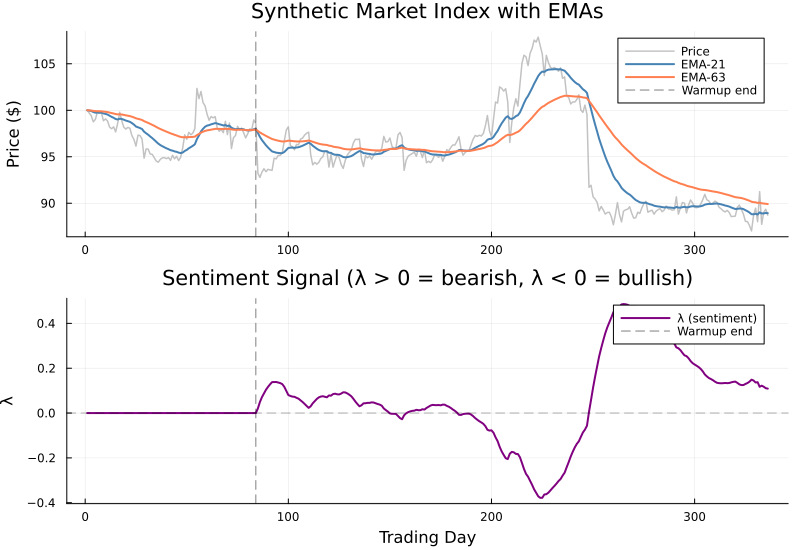

In [6]:
let
    T_total = length(market_prices);
    days = 1:T_total;

    # --- Top panel: market price with short and long EMAs ---
    p1 = plot(days, market_prices, label="Price", linewidth=1.5, color=:gray70, alpha=0.8)
    plot!(p1, days, ema_short, label="EMA-$(L_short)", linewidth=2, color=:steelblue)
    plot!(p1, days, ema_long, label="EMA-$(L_long)", linewidth=2, color=:coral)
    vline!(p1, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    ylabel!(p1, "Price (\$)")
    title!(p1, "Synthetic Market Index with EMAs")

    # --- Bottom panel: lambda sentiment signal ---
    p2 = plot(days, lambda_series, label="λ (sentiment)", linewidth=2, color=:purple)
    hline!(p2, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)  # zero reference line
    vline!(p2, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    xlabel!(p2, "Trading Day")
    ylabel!(p2, "λ")
    title!(p2, "Sentiment Signal (λ > 0 = bearish, λ < 0 = bullish)")

    # --- Combine into 2-row layout ---
    plot(p1, p2, layout=(2, 1), size=(800, 550), legend=:topright)
end

___
## Task 2: Cobb-Douglas Utility Allocation
Now we use the Cobb-Douglas utility function to allocate capital. At each time step, we compute preference weights $\gamma_i$ from SIM parameters and the current sentiment $\lambda_t$, then solve the analytical allocation:

$$n_i^{\star} = \frac{\gamma_i}{\sum_{j \in S^+} \gamma_j} \cdot \frac{B_{\text{adj}}}{P_i} \quad \text{(preferred)}, \qquad n_i^{\star} = \epsilon \quad \text{(non-preferred)}$$

where $B_{\text{adj}} = B - \epsilon \sum_{k \in S^-} P_k$ is the budget remaining after funding the minimum $\epsilon$ positions in the non-preferred set $S^-$. See the [Session 2 lecture](eCornell-AI-Finance-S2-Lecture-AIRebalancingEngine-May-2026.ipynb) for the full derivation.

To keep the notation aligned with the Session 2 lecture, we write the asset count as $N$, use the current price shorthand $P_i \equiv S_i(t)$, and interpret the one-step budget as $B \equiv W_{\mathcal{P}}(t)$. The optimal share counts $n_i^{\star}(t)$ map back to portfolio weights through $w_i(t) = n_i(t)S_i(t) / W_{\mathcal{P}}(t)$.

> __What should you see?__
>
> Preference weights shift over time as $\lambda$ changes. During bearish periods ($\lambda > 0$), high-$\beta$ assets should lose preference and the allocator should rotate toward lower-$\beta$ assets. During bullish periods ($\lambda < 0$), the ranking flips. Share allocations follow, with budget flowing toward whichever assets have the largest $\gamma_i$ on that day.

The `let...end` block below loops over trading days, calling [the `compute_preference_weights(...)` function](../../code/docs/build/session2.html) to obtain $\gamma_i$ values and then [the `allocate_cobb_douglas(...)` function](../../code/docs/build/session2.html) to solve for optimal shares. The cell returns `gamma_matrix::Matrix{Float64}` (shape $T_{\text{trade}} \times N$), `shares_matrix::Matrix{Float64}` (shape $T_{\text{trade}} \times N$), and `utility_series::Vector{Float64}` (length $T_{\text{trade}}$).

In [7]:
gamma_matrix, shares_matrix, utility_series = let
    T_trade = n_trading_days;

    # --- Step 1: Allocate storage for time series ---
    gamma_matrix  = zeros(T_trade, N);    # preference weights γᵢ at each trading day
    shares_matrix = zeros(T_trade, N);    # optimal share counts nᵢ* at each trading day
    utility_series = zeros(T_trade);       # Cobb-Douglas utility value at each trading day

    # --- Step 2: Loop over each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;                                         # full-series index (skip warmup)
        λ_t  = lambda_series[actual_day];                                # current sentiment signal
        gm_t = gm_ema[min(actual_day, length(gm_ema))];                  # smoothed market growth
        prices = [price_matrix[actual_day, k + 1] for k in 1:N];         # current prices for all N assets

        # --- Step 2a: Compute preference weights from SIM parameters + sentiment ---
        gamma = compute_preference_weights(sim_params, my_tickers, gm_t, λ_t);

        # --- Step 2b: Build and solve the Cobb-Douglas allocation problem ---
        problem = build(MyCobbDouglasChoiceProblem, (
            gamma = gamma, prices = prices, B = B₀, epsilon = ε
        ));
        (shares, cash) = allocate_cobb_douglas(problem);

        # --- Step 2c: Store results ---
        gamma_matrix[d, :]  = gamma;
        shares_matrix[d, :] = shares;
        utility_series[d]   = evaluate_cobb_douglas(shares, gamma);
    end

    println("Cobb-Douglas allocation computed for $(T_trade) trading days")
    println("Mean utility: $(round(mean(utility_series), digits=2))")
    gamma_matrix, shares_matrix, utility_series
end


Cobb-Douglas allocation computed for 252 trading days


Mean utility: -7.27393097445031e17


([-0.7767499278034825 -0.8965459531298134 … -0.9243695455767529 -0.864310009780341; -0.6354273581636118 -0.7805328022208187 … -0.808395166817554 -0.7154118033335365; … ; -0.11555049481720174 -0.17021104746737184 … -0.07532129045595752 -0.01430866690300214; -0.11537821902565515 -0.1700651283695545 … -0.07528174549619458 -0.014296305821839926], [0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], [-1.0490288377189574e18, -6.833392411741443e15, -1.0732141343933072e13, -7.010395398111234e12, -7.308808414301073e9, -6.375801055559107e8, -5.59669181510945e7, 40.25613138282119, -11.6654752751906, 126.06397643890976  …  -2.8394258606008826e11, 41.717475305492094, 20753.235135280796, -52685.50038756369, 4.3122648631510746e8, -2.731519707141244e9, -12.820033895038446, 145.18120833246735, -45.41441151694284, -45.3375542172851])

> __What should you see?__
>
> The top panel shows how each asset's preference weight moves with sentiment. Low-$\beta$ assets stay relatively stable because they're less sensitive to changes in $\lambda$; high-$\beta$ assets should swing the most. The bottom panel shows the resulting share counts, where budget flows to whichever assets carry the largest $\gamma_i$ at each trading day.

The code below plots the preference weights $\gamma_i$ over time (top panel) and the corresponding share allocations (bottom panel).

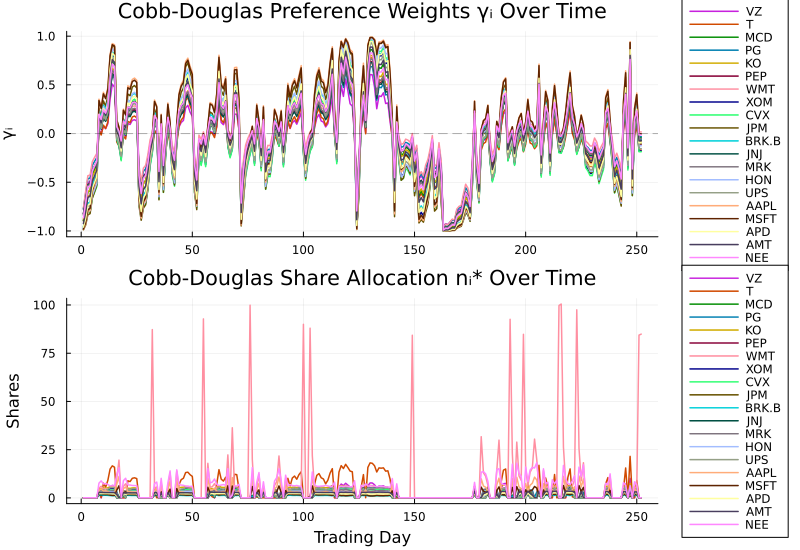

In [8]:
let
    days = 1:n_trading_days;
    palette = distinguishable_colors(N, [RGB(1,1,1), RGB(0,0,0)]; dropseed = true);

    # --- Top panel: preference weights γᵢ over time ---
    p1 = plot(size=(800, 250), title="Cobb-Douglas Preference Weights γᵢ Over Time",
        ylabel="γᵢ", legend=:outerright)
    for (k, ticker) in enumerate(my_tickers)
        plot!(p1, days, gamma_matrix[:, k], label=ticker, linewidth=1.5, color=palette[k])
    end
    hline!(p1, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)  # zero reference

    # --- Bottom panel: share allocations nᵢ* over time ---
    p2 = plot(size=(800, 250), title="Cobb-Douglas Share Allocation nᵢ* Over Time",
        xlabel="Trading Day", ylabel="Shares", legend=:outerright)
    for (k, ticker) in enumerate(my_tickers)
        plot!(p2, days, shares_matrix[:, k], label=ticker, linewidth=1.5, color=palette[k])
    end

    # --- Combine into 2-row layout ---
    plot(p1, p2, layout=(2, 1), size=(800, 550))
end

___
## Task 3: Compare Utility Functions (Cobb-Douglas vs. CES vs. Log-Linear)
We run the same scenario with three different utility functions and compare allocation behavior. The key question: **how does the choice of utility function affect portfolio concentration?**

CES with high $\sigma$ (elasticity of substitution) produces more concentrated portfolios, pushing more budget toward the single best asset. Cobb-Douglas is the middle ground. Log-linear produces the same allocation as Cobb-Douglas but different utility values.

> __What should you see?__
>
> Cobb-Douglas and log-linear allocations will be identical (the log transform preserves the optimum). CES with $\sigma = $ `CES_SIGMA_HIGH` will be more concentrated, with the top asset getting a larger share of the budget. CES with $\sigma = $ `CES_SIGMA_LOW` will be more diversified.

The `let...end` block below computes allocations for all four utility variants using [the `allocate_cobb_douglas(...)` function](../../code/docs/build/session2.html), [the `allocate_ces(...)` function](../../code/docs/build/session2.html), and [the `allocate_log_linear(...)` function](../../code/docs/build/session2.html). The cell returns eight arrays:
* `shares_cd::Matrix{Float64}`, `shares_ces_high::Matrix{Float64}`, `shares_ces_low::Matrix{Float64}`, `shares_ll::Matrix{Float64}` — each of shape $T_{\text{trade}} \times N$.
* `utility_cd::Vector{Float64}`, `utility_ces_high::Vector{Float64}`, `utility_ces_low::Vector{Float64}`, `utility_ll::Vector{Float64}` — each of length $T_{\text{trade}}$.

In [9]:
shares_cd, shares_ces_high, shares_ces_low, shares_ll, utility_cd, utility_ces_high, utility_ces_low, utility_ll = let
    T_trade = n_trading_days;

    # --- Step 1: Allocate storage for each utility variant ---
    shares_cd       = zeros(T_trade, N);   # Cobb-Douglas shares
    shares_ces_high = zeros(T_trade, N);   # CES σ = 3.0 (concentrated)
    shares_ces_low  = zeros(T_trade, N);   # CES σ = 0.5 (diversified)
    shares_ll       = zeros(T_trade, N);   # Log-linear shares

    utility_cd       = zeros(T_trade);     # Cobb-Douglas utility values
    utility_ces_high = zeros(T_trade);     # CES high-σ utility values
    utility_ces_low  = zeros(T_trade);     # CES low-σ utility values
    utility_ll       = zeros(T_trade);     # Log-linear utility values

    # --- Step 2: Loop over trading days and compute all allocations ---
    for d in 1:T_trade
        actual_day = offset + d;  # skip warmup
        λ_t  = lambda_series[actual_day];
        gm_t = gm_ema[min(actual_day, length(gm_ema))];
        prices = [price_matrix[actual_day, k + 1] for k in 1:N];

        # preference weights are the same for all utility functions
        gamma = compute_preference_weights(sim_params, my_tickers, gm_t, λ_t);

        # --- Cobb-Douglas allocation ---
        cd_prob = build(MyCobbDouglasChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε));
        (s_cd, _) = allocate_cobb_douglas(cd_prob);
        shares_cd[d, :] = s_cd;
        utility_cd[d]   = evaluate_cobb_douglas(s_cd, gamma);

        # --- CES high σ (concentrated, σ = 3.0) ---
        ces_h = build(MyCESChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε, sigma=CES_SIGMA_HIGH));
        (s_ces_h, _) = allocate_ces(ces_h);
        shares_ces_high[d, :] = s_ces_h;
        utility_ces_high[d]   = evaluate_ces(s_ces_h, gamma; sigma=CES_SIGMA_HIGH);

        # --- CES low σ (diversified, σ = 0.5) ---
        ces_l = build(MyCESChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε, sigma=CES_SIGMA_LOW));
        (s_ces_l, _) = allocate_ces(ces_l);
        shares_ces_low[d, :] = s_ces_l;
        utility_ces_low[d]   = evaluate_ces(s_ces_l, gamma; sigma=CES_SIGMA_LOW);

        # --- Log-linear allocation ---
        ll_prob = build(MyLogLinearChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε));
        (s_ll, _) = allocate_log_linear(ll_prob);
        shares_ll[d, :] = s_ll;
        utility_ll[d]   = evaluate_log_linear(s_ll, gamma);
    end

    # --- Step 3: Return results for downstream visualization ---
    shares_cd       = shares_cd;
    shares_ces_high = shares_ces_high;
    shares_ces_low  = shares_ces_low;
    shares_ll       = shares_ll;
    utility_cd       = utility_cd;
    utility_ces_high = utility_ces_high;
    utility_ces_low  = utility_ces_low;
    utility_ll       = utility_ll;

    println("Allocation computed for all 4 utility variants")
    shares_cd, shares_ces_high, shares_ces_low, shares_ll, utility_cd, utility_ces_high, utility_ces_low, utility_ll
end


Allocation computed for all 4 utility variants


([0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], [0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], [0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], [0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1; … ; 0.1 0.1 … 0.1 0.1; 0.1 0.1 … 0.1 0.1], [-1.0490288377189574e18, -6.833392411741443e15, -1.0732141343933072e13, -7.010395398111234e12, -7.308808414301073e9, -6.375801055559107e8, -5.59669181510945e7, 40.25613138282119, -11.6654752751906, 126.06397643890976  …  -2.8394258606008826e11, 41.717475305492094, 20753.235135280796, -52685.50038756369, 4.3122648631510746e8, -2.731519707141244e9, -12.820033895038446, 145.18120833246735, -45.41441151694284, -45.3375542172851], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 19.908306669334397, 13.178961854700423, 28.0310125760534  …  0.0, 19.344482234415974, 96.22733379605168, 0.0, 313.7231299687625, 0.0, 12.551376300694619, 28.197180504152087, 0.49439495871721434, 0.49668379

> __What should you see?__
>
> CES ($\sigma = 3$) should have the highest concentration, with more budget in the top asset. Cobb-Douglas and log-linear should be identical. CES ($\sigma = 0.5$) should be the most diversified.

The code below computes and plots the top-asset budget fraction over time for each utility function.

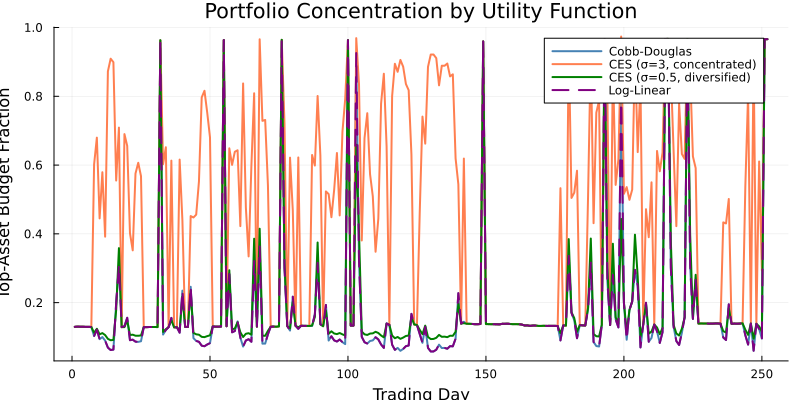

In [10]:
let
    T_trade = n_trading_days;

    # --- Step 1: Compute concentration metric for each utility variant ---
    f_cd = top_asset_fraction(shares_cd);
    f_ces_h = top_asset_fraction(shares_ces_high);
    f_ces_l = top_asset_fraction(shares_ces_low);
    f_ll = top_asset_fraction(shares_ll);

    # --- Step 2: Plot top-asset budget fraction over time ---
    days = 1:T_trade;
    plot(days, f_cd, label="Cobb-Douglas", linewidth=2, color=:steelblue)
    plot!(days, f_ces_h, label="CES (σ=3, concentrated)", linewidth=2, color=:coral)
    plot!(days, f_ces_l, label="CES (σ=0.5, diversified)", linewidth=2, color=:green)
    plot!(days, f_ll, label="Log-Linear", linewidth=2, color=:purple, linestyle=:dash)
    xlabel!("Trading Day")
    ylabel!("Top-Asset Budget Fraction")
    title!("Portfolio Concentration by Utility Function")
    plot!(size=(800, 400), legend=:topright)
end

The code below computes summary statistics (mean and standard deviation of the Herfindahl-Hirschman Index) for each utility function and displays them using [`pretty_table`](https://ronisbr.github.io/PrettyTables.jl/stable/).

In [11]:
let
    # --- Step 1: Compute HHI for each utility variant ---
    names = ["Cobb-Douglas", "CES (σ=3.0)", "CES (σ=0.5)", "Log-Linear"];
    mats  = [shares_cd, shares_ces_high, shares_ces_low, shares_ll];
    stats = [concentration_stats(m) for m ∈ mats];

    # --- Step 2: Build the summary DataFrame ---
    df = DataFrame(
        "Utility Function" => names,
        "Mean HHI"         => [s.mean for s ∈ stats],
        "Std HHI"          => [s.std  for s ∈ stats],
    );

    # --- Step 3: Display ---
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------------ ---------- ---------
  Utility Function   Mean HHI   Std HHI 
            String    Float64   Float64 
 ------------------ ---------- ---------
      Cobb-Douglas     0.1255    0.1889
       CES (σ=3.0)     0.3541    0.2837
       CES (σ=0.5)     0.1241    0.1816
        Log-Linear     0.1255    0.1889
 ------------------ ---------- ---------


___
### Hand-off to the next notebook
We now construct the rebalancing engine context and save the artifacts the next notebook will consume. The `let...end` block below builds a [`MyRebalancingContextModel`](../../code/docs/build/session2.html) from the single-path price data, precomputes three baseline wealth series (S1 min-var buy-and-hold, equal-weight buy-and-hold, and the deterministic risk-free curve at rate `g_f`), and writes `engine-run-data.jld2` to the Session 2 data directory. The downstream `RebalancingEngineScorecard` notebook loads this file verbatim.

In [12]:
let
    # --- Step 1: Build the rebalancing engine context from the single-path data ---
    context = build(MyRebalancingContextModel, (
        B              = B₀,
        tickers        = my_tickers,
        marketdata     = price_matrix,
        marketfactor   = gm_ema,
        sim_parameters = sim_params,
        lambda         = 0.0,        # placeholder; the engine pulls λ_t from lambda_series
        Δt             = Δt,
        epsilon        = ε,
    ));

    # --- Step 2: Three baseline wealth series on this single path ---
    eqw = fill(1.0 / N, N);
    minvar_wealth      = buyhold_series(minvar_weights, price_matrix, offset, B₀);
    equalweight_wealth = buyhold_series(eqw,            price_matrix, offset, B₀);
    riskfree_wealth    = [B₀ * exp(g_f * (t - 1) * Δt) for t ∈ 1:n_trading_days];

    # --- Step 3: Save everything the next notebook needs ---
    save_path = joinpath(_PATH_TO_DATA, "engine-run-data.jld2");
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "price_matrix"       => price_matrix,
        "market_prices"      => market_prices,
        "lambda_series"      => lambda_series,
        "gm_ema"             => gm_ema,
        "sim_params"         => sim_params,
        "context"            => context,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
        "minvar_weights"     => minvar_weights,
        "g_f"                => g_f,
        "B₀"                 => B₀,
    ));

    println("Saved engine run data to: $(save_path)")
    println("  $(N) tickers, $(T_total) total days ($(offset) warmup + $(n_trading_days) trading)")
    println("  Baselines (final W / W₀): ",
        "minvar=", round(minvar_wealth[end] / B₀, digits=3),
        ", eq-wt=", round(equalweight_wealth[end] / B₀, digits=3),
        ", rf=",    round(riskfree_wealth[end]  / B₀, digits=3))
end

Saved engine run data to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-2/data/engine-run-data.jld2


  20 tickers, 336 total days (84 warmup + 252 trading)
  Baselines (final W / W₀): minvar=1.049, eq-wt=0.937, rf=1.046


___
## Summary
The Cobb-Douglas allocator translates SIM-based preference weights and EMA crossover sentiment into budget-constrained share allocations that adapt as market conditions change. In this example we loaded the user-selected universe and calibrated SIM parameters from Session 1, generated one hybrid-SIM forward path, solved the Cobb-Douglas allocation on each trading day, compared Cobb-Douglas against CES and log-linear alternatives, and wrote the single-path data to `engine-run-data.jld2` for the next notebook.

> __Key Takeaways:__
>
> * __Cobb-Douglas and log-linear produce identical allocations:__ The log transform preserves the optimum, so the choice between them only matters when utility values are used as reward signals. Both yield the same share counts for the same preference weights.
> * __CES elasticity controls concentration:__ High elasticity of substitution concentrates the portfolio toward the top asset, while low elasticity diversifies across all assets. This provides a single parameter to tune conviction versus robustness.
> * __Preference weights bridge fundamentals and sentiment:__ The preference weights combine the Session 1 SIM parameters with the EMA crossover signal, so the allocator adapts as market conditions change without manual reweighting. This closes the feedback loop that was missing in the static Session 1 portfolio.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___